In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('PJMW_hourly_cleaned_edit.csv')

print("Rows:", len(df))
print("Last raw date:", df["Datetime"].iloc[-1])
print("Last date:", pd.to_datetime(df["Datetime"]).max())

df.head()

Rows: 143206
Last raw date: 2018-08-03 00:00:00
Last date: 2018-08-03 00:00:00


,Datetime,PJMW_MW,year,month,day,hour,Dayofweek,isweekend,Is_Holiday,Season
0,2002-04-01 01:00:00,4374.0,2002,4,1,1,0,0,False,Spring
1,2002-04-01 02:00:00,4306.0,2002,4,1,2,0,0,False,Spring
2,2002-04-01 03:00:00,4322.0,2002,4,1,3,0,0,False,Spring
3,2002-04-01 04:00:00,4359.0,2002,4,1,4,0,0,False,Spring
4,2002-04-01 05:00:00,4436.0,2002,4,1,5,0,0,False,Spring


In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

print("First date:", df["Datetime"].min())
print("Last date:", df["Datetime"].max())

First date: 2002-04-01 01:00:00
Last date: 2018-08-03 00:00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Datetime    143206 non-null  datetime64[ns]
 1   PJMW_MW     143206 non-null  float64       
 2   year        143206 non-null  int64         
 3   month       143206 non-null  int64         
 4   day         143206 non-null  int64         
 5   hour        143206 non-null  int64         
 6   Dayofweek   143206 non-null  int64         
 7   isweekend   143206 non-null  int64         
 8   Is_Holiday  143206 non-null  bool          
 9   Season      143206 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 10.0+ MB


In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

In [ ]:
df.shape

(143206, 10)

In [ ]:
# Check duplicate timestamps
duplicates = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

print("Number of duplicate rows:", len(duplicates))

duplicates

Number of duplicate rows: 8


,Datetime,PJMW_MW,year,month,day,hour,Dayofweek,isweekend,Is_Holiday,Season
110327,2014-11-02 02:00:00,4571.0,2014,11,2,2,6,1,False,Fall
110328,2014-11-02 02:00:00,4613.0,2014,11,2,2,6,1,False,Fall
119063,2015-11-01 02:00:00,3927.0,2015,11,1,2,6,1,False,Fall
119064,2015-11-01 02:00:00,3832.0,2015,11,1,2,6,1,False,Fall
127967,2016-11-06 02:00:00,4114.0,2016,11,6,2,6,1,False,Fall
127968,2016-11-06 02:00:00,4089.0,2016,11,6,2,6,1,False,Fall
136703,2017-11-05 02:00:00,3984.0,2017,11,5,2,6,1,False,Fall
136704,2017-11-05 02:00:00,4042.0,2017,11,5,2,6,1,False,Fall


In [ ]:
print("Unique timestamps:", df["Datetime"].nunique())
print("Total rows:", len(df))

Unique timestamps: 143202
Total rows: 143206


In [ ]:
# Check the duplicate timestamps and their consumption values
duplicates.groupby("Datetime")["PJMW_MW"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Datetime,,,,
2014-11-02 02:00:00,2,4592.0,4571.0,4613.0
2015-11-01 02:00:00,2,3879.5,3832.0,3927.0
2016-11-06 02:00:00,2,4101.5,4089.0,4114.0
2017-11-05 02:00:00,2,4013.0,3984.0,4042.0


In [ ]:
df = df.groupby("Datetime", as_index=False).agg({
    "PJMW_MW": "mean",
    "year": "first",
    "month": "first",
    "day": "first",
    "hour": "first",
    "Dayofweek": "first",
    "isweekend": "first",
    "Is_Holiday": "first",
    "Season": "first"
})

In [ ]:
df = df.sort_values("Datetime").reset_index(drop=True)

In [ ]:
print("Rows:", len(df))
print("Unique timestamps:", df["Datetime"].nunique())

Rows: 143202
Unique timestamps: 143202


In [ ]:
time_diff = df["Datetime"].diff()

print(time_diff.value_counts().head(10))

Datetime
0 days 01:00:00    143171
0 days 02:00:00        30
Name: count, dtype: int64


In [ ]:
gaps = df.loc[
    time_diff > pd.Timedelta(hours=1),
    ["Datetime"]
]

gaps

,Datetime
146,2002-04-07 04:00:00
5016,2002-10-27 03:00:00
8880,2003-04-06 04:00:00
13750,2003-10-26 03:00:00
17614,2004-04-04 04:00:00
22652,2004-10-31 03:00:00
26348,2005-04-03 04:00:00
31386,2005-10-30 03:00:00
35082,2006-04-02 04:00:00
40120,2006-10-29 03:00:00


## Feature Engineering

## Create lag_1

In [ ]:
df["lag_1"] = df["PJMW_MW"].shift(1)

## Create a proper 24-hour lag

In [ ]:
lag_24 = df[["Datetime", "PJMW_MW"]].copy()

lag_24["Datetime"] = lag_24["Datetime"] + pd.Timedelta(hours=24)

lag_24 = lag_24.rename(
    columns={"PJMW_MW": "lag_24"}
)

df = df.merge(
    lag_24,
    on="Datetime",
    how="left"
)

In [ ]:
df[["Datetime", "PJMW_MW", "lag_24"]].head(30)

,Datetime,PJMW_MW,lag_24
0,2002-04-01 01:00:00,4374.0,NaN
1,2002-04-01 02:00:00,4306.0,NaN
2,2002-04-01 03:00:00,4322.0,NaN
3,2002-04-01 04:00:00,4359.0,NaN
4,2002-04-01 05:00:00,4436.0,NaN
5,2002-04-01 06:00:00,4723.0,NaN
6,2002-04-01 07:00:00,5180.0,NaN
7,2002-04-01 08:00:00,5482.0,NaN
8,2002-04-01 09:00:00,5616.0,NaN
9,2002-04-01 10:00:00,5722.0,NaN


## Create 7-day lag

In [ ]:
lag_168 = df[["Datetime", "PJMW_MW"]].copy()

lag_168["Datetime"] = (
    lag_168["Datetime"] + pd.Timedelta(hours=168)
)

lag_168 = lag_168.rename(
    columns={"PJMW_MW": "lag_168"}
)

df = df.merge(
    lag_168,
    on="Datetime",
    how="left"
)

df[["Datetime", "PJMW_MW", "lag_24", "lag_168"]].tail()

## Cyclical features

In [ ]:
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

In [ ]:
df["dow_sin"] = np.sin(
    2 * np.pi * df["Dayofweek"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["Dayofweek"] / 7
)

## Rolling averages

### 24-hour rolling average

In [ ]:
df["rolling_24"] = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

### 7-day rolling average

In [ ]:
df["rolling_168"] = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

In [ ]:
df.head()

,Datetime,PJMW_MW,year,month,day,hour,Dayofweek,isweekend,Is_Holiday,Season,lag_1,lag_24,lag_168,hour_sin,hour_cos,dow_sin,dow_cos,rolling_24,rolling_168
0,2002-04-01 01:00:00,4374.0,2002,4,1,1,0,0,False,Spring,NaN,NaN,NaN,0.258819,0.965926,0.0,1.0,NaN,NaN
1,2002-04-01 02:00:00,4306.0,2002,4,1,2,0,0,False,Spring,4374.0,NaN,NaN,0.500000,0.866025,0.0,1.0,NaN,NaN
2,2002-04-01 03:00:00,4322.0,2002,4,1,3,0,0,False,Spring,4306.0,NaN,NaN,0.707107,0.707107,0.0,1.0,NaN,NaN
3,2002-04-01 04:00:00,4359.0,2002,4,1,4,0,0,False,Spring,4322.0,NaN,NaN,0.866025,0.500000,0.0,1.0,NaN,NaN
4,2002-04-01 05:00:00,4436.0,2002,4,1,5,0,0,False,Spring,4359.0,NaN,NaN,0.965926,0.258819,0.0,1.0,NaN,NaN


In [ ]:
df.isna().sum()

Datetime         0
PJMW_MW          0
year             0
month            0
day              0
hour             0
Dayofweek        0
isweekend        0
Is_Holiday       0
Season           0
lag_1            1
lag_24          54
lag_168        197
hour_sin         0
hour_cos         0
dow_sin          0
dow_cos          0
rolling_24      24
rolling_168    168
dtype: int64

In [ ]:
df.shape

(143202, 19)

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,Datetime,PJMW_MW,year,month,day,hour,Dayofweek,isweekend,Is_Holiday,Season,lag_1,lag_24,lag_168,hour_sin,hour_cos,dow_sin,dow_cos,rolling_24,rolling_168
0,2002-04-08 02:00:00,4532.0,2002,4,8,2,0,0,False,Spring,4634.0,4858.0,4306.0,0.500000,8.660254e-01,0.0,1.0,5029.625000,5379.339286
1,2002-04-08 04:00:00,4527.0,2002,4,8,4,0,0,False,Spring,4481.0,4871.0,4359.0,0.866025,5.000000e-01,0.0,1.0,4994.333333,5381.321429
2,2002-04-08 05:00:00,4640.0,2002,4,8,5,0,0,False,Spring,4527.0,4909.0,4436.0,0.965926,2.588190e-01,0.0,1.0,4980.000000,5382.541667
3,2002-04-08 06:00:00,4940.0,2002,4,8,6,0,0,False,Spring,4640.0,5038.0,4723.0,1.000000,6.123234e-17,0.0,1.0,4968.791667,5384.214286
4,2002-04-08 07:00:00,5528.0,2002,4,8,7,0,0,False,Spring,4940.0,5196.0,5180.0,0.965926,-2.588190e-01,0.0,1.0,4964.708333,5387.214286


## Train/Test Split

### Find the test period

In [ ]:
last_date = df["Datetime"].max()

test_start = last_date - pd.DateOffset(years=1)

print("Last date:", last_date)
print("Test starts:", test_start)

Last date: 2018-08-03 00:00:00
Test starts: 2017-08-03 00:00:00


### Split the data


In [ ]:
train = df[df["Datetime"] < test_start].copy()

test = df[df["Datetime"] >= test_start].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train period:")
print(train["Datetime"].min(), "to", train["Datetime"].max())

print("\nTest period:")
print(test["Datetime"].min(), "to", test["Datetime"].max())

Train shape: (134216, 19)
Test shape: (8758, 19)
Train period:
2002-04-08 02:00:00 to 2017-08-02 23:00:00

Test period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00


In [ ]:
features = [
    "hour",
    "Dayofweek",
    "isweekend",
    "Is_Holiday",
    "month",
    "year",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24",
    "rolling_168",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

target = "PJMW_MW"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (134216, 15)
y_train: (134216,)
X_test: (8758, 15)
y_test: (8758,)


## Baseline Model

In [ ]:
from sklearn.metrics import  mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
baseline_pred = X_test["lag_24"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_mape = mean_absolute_percentage_error(
    y_test,
    baseline_pred
)

print("Baseline Model")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape * 100, "%")

Baseline Model
----------------
MAE : 382.682119205298
RMSE: 501.4008403410181
MAPE: 6.663326824099874 %


## RandomForest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)



rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_pred
)

print("Random Forest")
print("----------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape * 100, "%")

Random Forest
----------------
MAE : 58.961546008506
RMSE: 77.40909257795214
MAPE: 1.0305999989391275 %


In [ ]:
print("Baseline MAPE :", baseline_mape * 100, "%")
print("Random Forest MAPE:", rf_mape * 100, "%")

print("Baseline MAE :", baseline_mae)
print("Random Forest MAE:", rf_mae)

print("Baseline RMSE :", baseline_rmse)
print("Random Forest RMSE:", rf_rmse)




Baseline MAPE : 6.663326824099876 %
Random Forest MAPE: 1.0305999989391275 %
Baseline MAE : 382.682119205298
Random Forest MAE: 58.961546008506
Baseline RMSE : 501.4008403410181
Random Forest RMSE: 77.40909257795214


## XGBoost Model

In [ ]:
X_train['Is_Holiday'] = X_train['Is_Holiday'].astype(int)
X_test['Is_Holiday'] = X_test['Is_Holiday'].astype(int)

/tmp/ipykernel_3259/1426869431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Is_Holiday'] = X_train['Is_Holiday'].astype(int)
/tmp/ipykernel_3259/1426869431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Is_Holiday'] = X_test['Is_Holiday'].astype(int)


In [ ]:
!pip install xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 1.5 MB/s eta 0:00:00


## Model Evaluation

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

print("XGBoost")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape * 100, "%")

XGBoost
----------------
MAE : 56.9358426704067
RMSE: 79.14336563560732
MAPE: 0.9809011305854339 %


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAPE (%)": [
        baseline_mape * 100,
        rf_mape * 100,
        xgb_mape * 100
    ]
})

results

,Model,MAE,RMSE,MAPE (%)
0,Baseline,382.682119,501.400840,6.663327
1,Random Forest,58.961546,77.409093,1.030600
2,XGBoost,56.935843,79.143366,0.980901


## XGBOOST Actual vs Pridicted

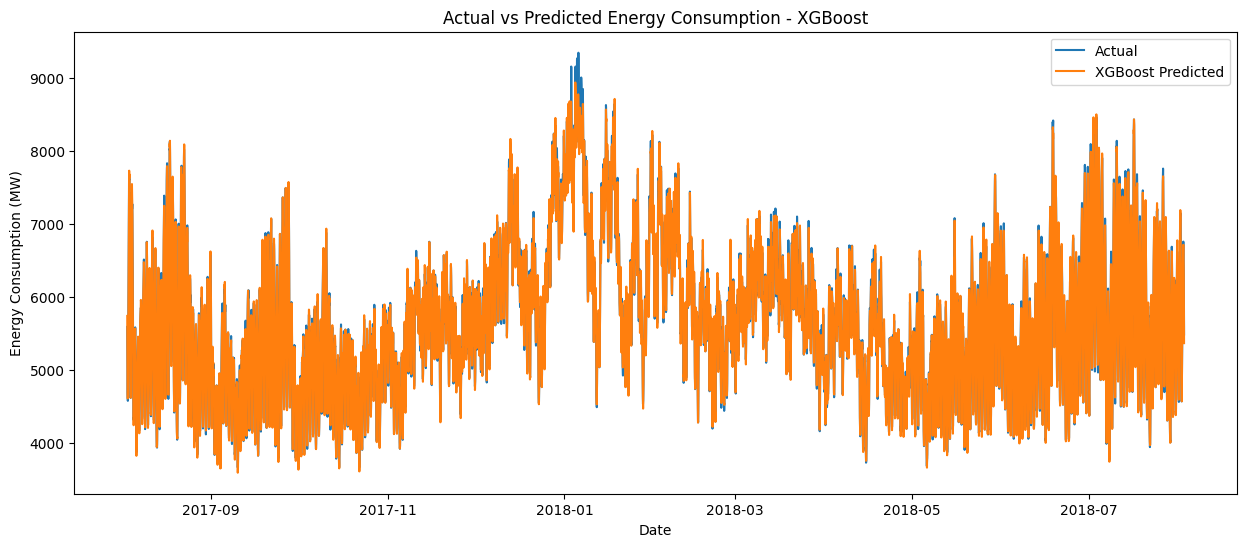

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Datetime"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Datetime"],
    xgb_pred,
    label="XGBoost Predicted"
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("Actual vs Predicted Energy Consumption - XGBoost")

plt.legend()
plt.show()

## Tuning RandomForest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Define the hyperparameter search space for Random Forest
rf_param_distributions = {
    'n_estimators': [100, 200, 300, 500, 800],        # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None],           # Number of features to consider at every split (None = all features)
    'max_depth': [None, 10, 20, 30, 40, 50],          # Maximum number of levels in each decision tree
    'min_samples_split': [2, 5, 10],                  # Minimum number of data points placed in a node before the node is split
    'min_samples_leaf': [1, 2, 4],                    # Minimum number of data points allowed in a leaf node
    'bootstrap': [True, False]                        # Method of selecting samples for training each tree
}

# 2. Instantiate the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 3. Setup RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    n_iter=30,                             # Try 30 random combinations
    scoring='neg_mean_absolute_error',     # Optimize for lowest MAE
    cv=5,                                  # 5-fold cross-validation
    verbose=2,                             # Print progress
    random_state=42,
    n_jobs=-1                              # Use all CPU cores
)

# 4. Fit the random search to the training data
print("Starting Random Search for Random Forest...")
rf_random_search.fit(X_train, y_train)

# 5. Print the best parameters found
print("\nBest Parameters found: ")
print(rf_random_search.best_params_)



Starting Random Search for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters found: 
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': True}


## Tuned RandomForestModel

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Tuned_rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
    max_features=None,
    bootstrap=True
)



Tuned_rf_model.fit(X_train, y_train)
Tuned_rf_pred = Tuned_rf_model.predict(X_test)

## Tuned RandomForest Model Evalution

In [ ]:
Tuned_rf_mae = mean_absolute_error(y_test, Tuned_rf_pred)

Tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, Tuned_rf_pred)
)

Tuned_rf_mape = mean_absolute_percentage_error(
    y_test,
    Tuned_rf_pred
)

print("Tuned Random Forest")
print("----------------")
print("MAE :", Tuned_rf_mae)
print("RMSE:", Tuned_rf_rmse)
print("MAPE:", Tuned_rf_mape * 100, "%")

Tuned Random Forest
----------------
MAE : 59.1220984305839
RMSE: 77.68949716953848
MAPE: 1.0329567425694894 %


## Tunening XGBOOST Model

In [ ]:

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
# 1. Define the hyperparameter search space
param_distributions = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9, 11],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=30,                     # Number of random combinations to try (adjust based on your time)
    scoring='neg_mean_absolute_error', # Optimizing for MAE
    cv=5,                          # 5-fold cross-validation
    verbose=2,                     # Prints the progress out as it runs
    random_state=42,
    n_jobs=-1                      # Uses all available CPU cores
)

print("Starting Random Search...")
random_search.fit(X_train, y_train)
print("\nBest Parameters found: ")
print(random_search.best_params_)

Starting Random Search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters found: 
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


## Tuned XGBOOST Model

In [ ]:
from xgboost import XGBRegressor

Tuned_xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
)


Tuned_xgb_model.fit(X_train, y_train)
Tuned_xgb_pred = Tuned_xgb_model.predict(X_test)

## Tuned Model Evalution

In [ ]:
Tuned_xgb_mae = mean_absolute_error(y_test, Tuned_xgb_pred)

Tuned_xgb_rmse = np.sqrt(
    mean_squared_error(y_test, Tuned_xgb_pred)
)

Tuned_xgb_mape = mean_absolute_percentage_error(
    y_test,
    Tuned_xgb_pred
)

print("XGBoost Tuned")
print("----------------")
print("MAE :", Tuned_xgb_mae)
print("RMSE:", Tuned_xgb_rmse)
print("MAPE:", Tuned_xgb_mape * 100, "%")

XGBoost Tuned
----------------
MAE : 56.50017765565233
RMSE: 79.25301775040074
MAPE: 0.9744700492953617 %


## Random Forest Actual vs Pridicted

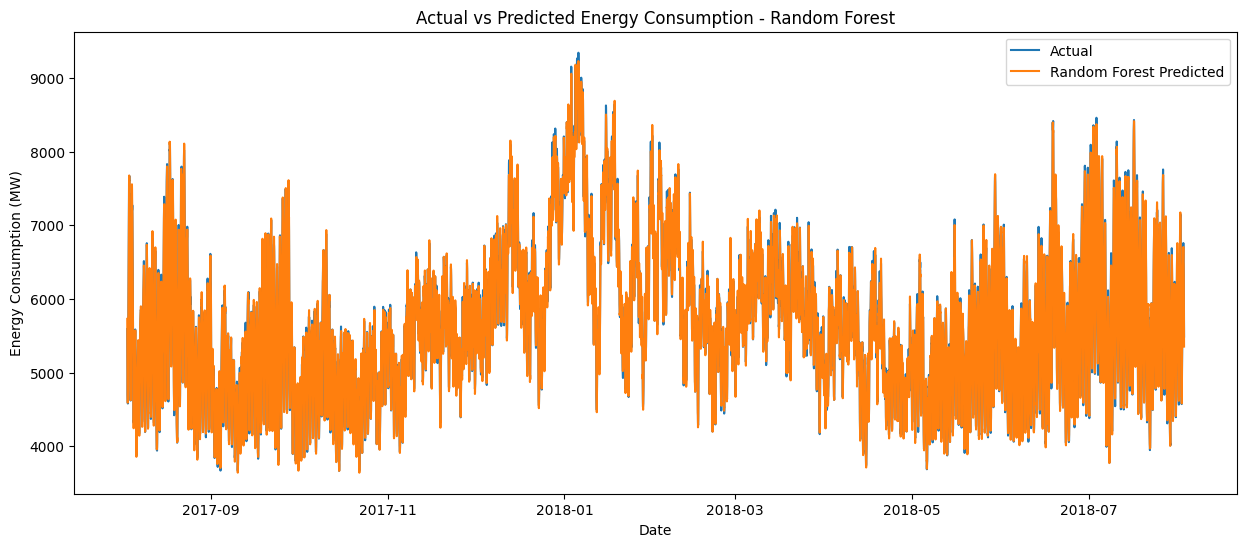

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Datetime"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Datetime"],
    rf_pred,
    label="Random Forest Predicted"
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("Actual vs Predicted Energy Consumption - Random Forest")

plt.legend()
plt.show()

In [ ]:
xgb_results = test[["Datetime", "PJMW_MW"]].copy()

xgb_results["Predicted"] = xgb_pred

xgb_results["Error"] = (
    xgb_results["PJMW_MW"] -
    xgb_results["Predicted"]
)

xgb_results["Absolute_Error"] = (
    xgb_results["Error"].abs()
)

xgb_results.head()

,Datetime,PJMW_MW,Predicted,Error,Absolute_Error
134216,2017-08-03 00:00:00,5591.0,5741.332520,-150.332520,150.332520
134217,2017-08-03 01:00:00,5170.0,5209.627441,-39.627441,39.627441
134218,2017-08-03 02:00:00,4948.0,4894.465820,53.534180,53.534180
134219,2017-08-03 03:00:00,4700.0,4777.178223,-77.178223,77.178223
134220,2017-08-03 04:00:00,4606.0,4612.217773,-6.217773,6.217773


In [ ]:
xgb_results["Absolute_Error"].describe()

,Absolute_Error
count,8758.000000
mean,56.935843
std,54.975697
min,0.011230
25%,20.719727
50%,43.914795
75%,78.060669
max,759.219727


## Peak Error Analysis

In [ ]:
# Add predictions to test data
comparison = test[["Datetime", "PJMW_MW"]].copy()

comparison["RF_Predicted"] = rf_pred
comparison["XGB_Predicted"] = xgb_pred

comparison["RF_Error"] = (
    comparison["PJMW_MW"] - comparison["RF_Predicted"]
).abs()

comparison["XGB_Error"] = (
    comparison["PJMW_MW"] - comparison["XGB_Predicted"]
).abs()

comparison.head()

,Datetime,PJMW_MW,RF_Predicted,XGB_Predicted,RF_Error,XGB_Error
134216,2017-08-03 00:00:00,5591.0,5728.858701,5741.332520,137.858701,150.332520
134217,2017-08-03 01:00:00,5170.0,5177.166569,5209.627441,7.166569,39.627441
134218,2017-08-03 02:00:00,4948.0,4892.206617,4894.465820,55.793383,53.534180
134219,2017-08-03 03:00:00,4700.0,4765.005416,4777.178223,65.005416,77.178223
134220,2017-08-03 04:00:00,4606.0,4591.413308,4612.217773,14.586692,6.217773


### 10 largest XGBoost errors:

In [ ]:
comparison.sort_values(
    "XGB_Error",
    ascending=False
).head(10)

,Datetime,PJMW_MW,RF_Predicted,XGB_Predicted,RF_Error,XGB_Error
137956,2018-01-05 20:00:00,9342.0,9218.545000,8582.780273,123.455000,759.219727
137957,2018-01-05 21:00:00,9252.0,9161.485000,8537.908203,90.515000,714.091797
135697,2017-10-03 17:00:00,5410.0,4690.210261,4705.551270,719.789739,704.448730
137947,2018-01-05 11:00:00,9023.0,9007.670000,8349.229492,15.330000,673.770508
137955,2018-01-05 19:00:00,9325.0,9228.340000,8668.634766,96.660000,656.365234
137897,2018-01-03 09:00:00,9146.0,9055.855000,8494.479492,90.145000,651.520508
137946,2018-01-05 10:00:00,9155.0,9113.170000,8530.382812,41.830000,624.617188
137958,2018-01-05 22:00:00,9024.0,9087.575000,8400.941406,63.575000,623.058594
137980,2018-01-06 20:00:00,8947.0,8918.130000,8346.425781,28.870000,600.574219
137979,2018-01-06 19:00:00,9003.0,8948.765000,8411.582031,54.235000,591.417969


### 10 largest Random Forest errors

In [ ]:
comparison.sort_values(
    "RF_Error",
    ascending=False
).head(10)

,Datetime,PJMW_MW,RF_Predicted,XGB_Predicted,RF_Error,XGB_Error
135697,2017-10-03 17:00:00,5410.0,4690.210261,4705.551270,719.789739,704.448730
135696,2017-10-03 16:00:00,4608.0,5148.606253,5146.741699,540.606253,538.741699
137930,2018-01-04 18:00:00,8951.0,8474.770247,8935.311523,476.229753,15.688477
137954,2018-01-05 18:00:00,9310.0,8923.330000,8772.796875,386.670000,537.203125
137834,2017-12-31 18:00:00,8145.0,7772.371575,7994.285645,372.628425,150.714355
135860,2017-10-10 12:00:00,6123.0,5754.599019,5830.031738,368.400981,292.968262
137378,2017-12-12 18:00:00,7669.0,7324.029058,7533.278320,344.970942,135.721680
136994,2017-11-26 18:00:00,5765.0,5426.704177,5610.464844,338.295823,154.535156
137781,2017-12-29 13:00:00,7415.0,7742.719412,7630.479004,327.719412,215.479004
137762,2017-12-28 18:00:00,8140.0,7818.472152,8057.705078,321.527848,82.294922


In [ ]:
hour_performance = comparison.copy()

hour_performance["Hour"] = (
    hour_performance["Datetime"].dt.hour
)

hour_performance.groupby("Hour").agg(
    RF_MAE=("RF_Error", "mean"),
    XGB_MAE=("XGB_Error", "mean")
)

,RF_MAE,XGB_MAE
Hour,,
0,59.319576,51.887084
1,59.705146,48.572110
2,45.166832,42.211014
3,35.794238,35.655149
4,36.607686,38.137951
5,39.839211,39.768024
6,45.880553,41.103936
7,59.068318,53.719832
8,49.393229,54.595733


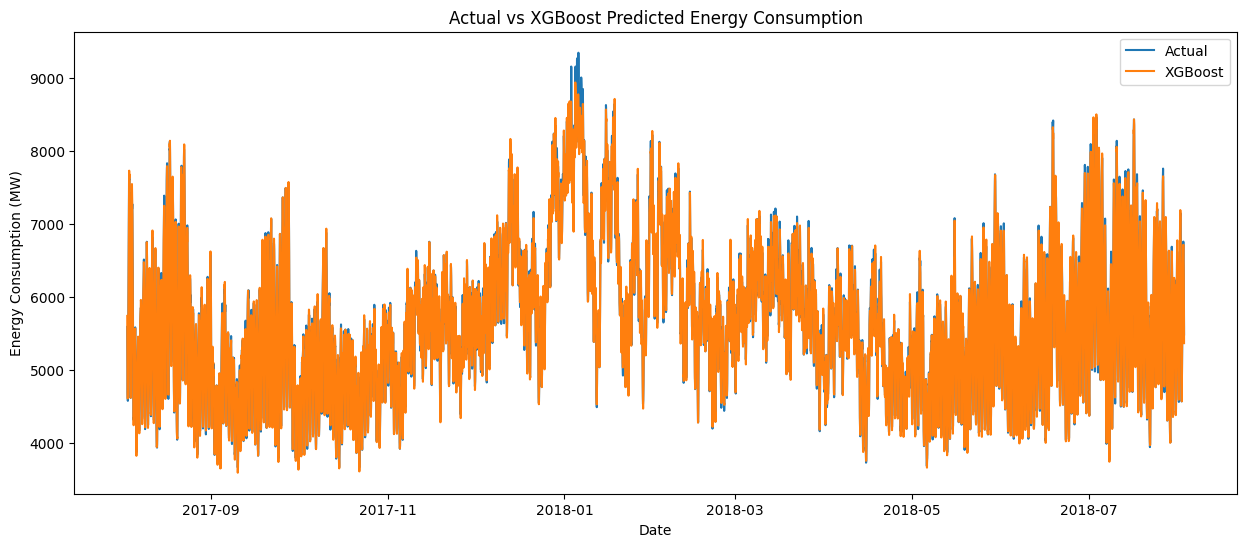

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    test["Datetime"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Datetime"],
    xgb_pred,
    label="XGBoost"
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("Actual vs XGBoost Predicted Energy Consumption")

plt.legend()
plt.show()

## Feature Importance

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
6,lag_1,0.950570
12,hour_cos,0.022830
0,hour,0.009819
11,hour_sin,0.005280
4,month,0.003521
9,rolling_24,0.002631
7,lag_24,0.001194
10,rolling_168,0.001011
8,lag_168,0.000861
5,year,0.000705


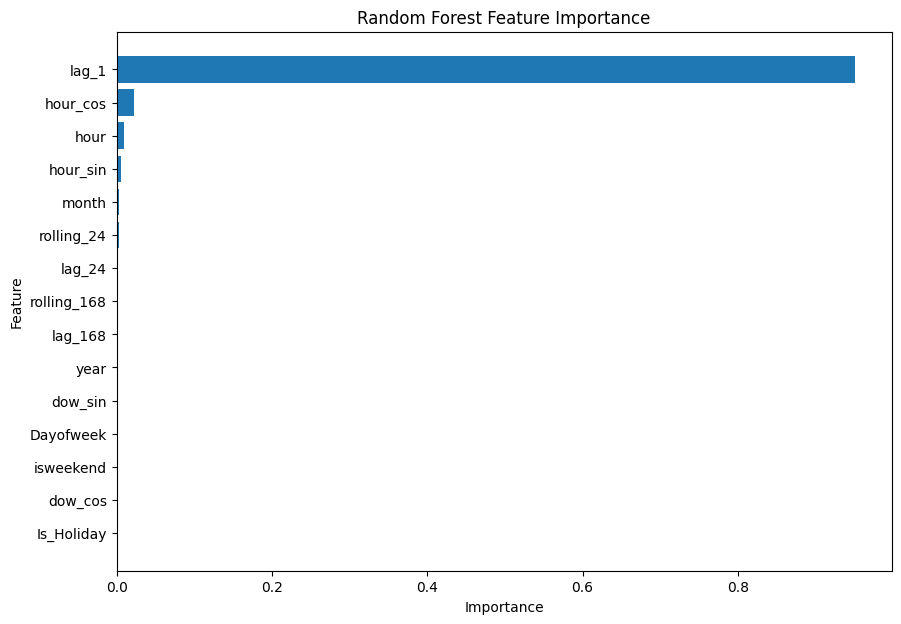

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
6,lag_1,0.716035
7,lag_24,0.120285
12,hour_cos,0.039533
2,isweekend,0.039018
14,dow_cos,0.022326
8,lag_168,0.013625
0,hour,0.011463
1,Dayofweek,0.009156
13,dow_sin,0.007832
11,hour_sin,0.006702


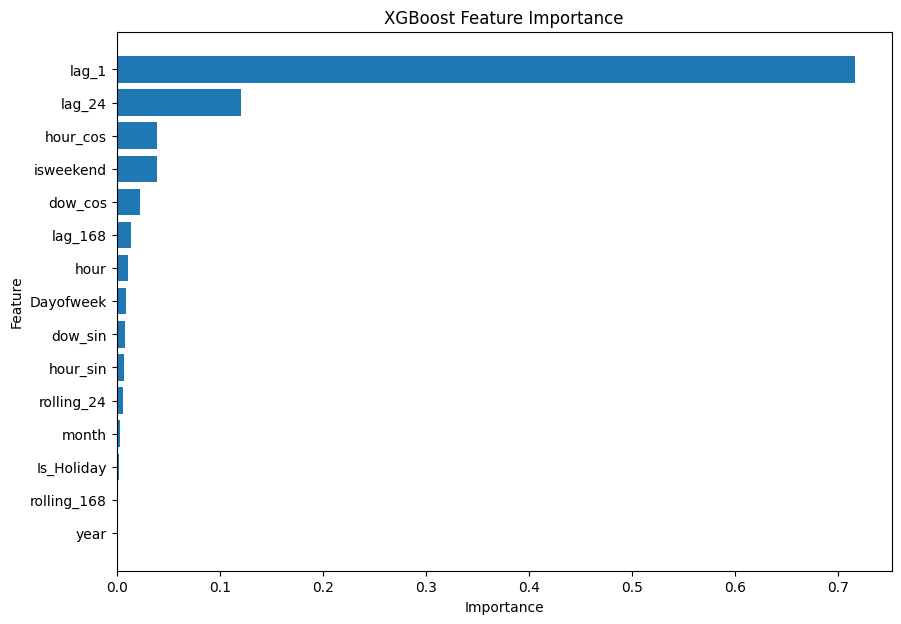

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
peak_threshold = test["PJMW_MW"].quantile(0.90)

peak_data = comparison[
    comparison["PJMW_MW"] >= peak_threshold
]

print("Peak demand threshold:", peak_threshold)
print("Peak observations:", len(peak_data))

print("\nRandom Forest Peak MAE:",
      peak_data["RF_Error"].mean())

print("XGBoost Peak MAE:",
      peak_data["XGB_Error"].mean())

Peak demand threshold: 7039.3
Peak observations: 876

Random Forest Peak MAE: 79.64748840062113
XGBoost Peak MAE: 96.8335919663242


## LSTM Model

LSTM is a sequence model, so unlike Random Forest and XGBoost, it learns patterns from a window of previous observations. Here we use the previous 168 hours (7 days) of engineered features to predict the next hourly demand.


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Use the same feature set as the tree-based models
lstm_features = features.copy()
sequence_length = 168  # Previous 7 days

# Scale features using ONLY the training data
feature_scaler = StandardScaler()
feature_scaler.fit(X_train)

X_all_scaled = feature_scaler.transform(df[lstm_features])
y_all = df[target].values
dates_all = df['Datetime'].values

# Build sequences. Each sequence ends at the timestamp being predicted.
X_seq = []
y_seq = []
seq_dates = []

for i in range(sequence_length, len(df)):
    X_seq.append(X_all_scaled[i-sequence_length:i])
    y_seq.append(y_all[i])
    seq_dates.append(dates_all[i])

X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)
seq_dates = pd.to_datetime(seq_dates)

# Keep the chronological train/test split
train_mask = seq_dates < pd.Timestamp(test_start)
test_mask = seq_dates >= pd.Timestamp(test_start)

X_lstm_train = X_seq[train_mask]
y_lstm_train = y_seq[train_mask]
X_lstm_test = X_seq[test_mask]
y_lstm_test = y_seq[test_mask]

print('LSTM train shape:', X_lstm_train.shape)
print('LSTM test shape :', X_lstm_test.shape)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 783.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


LSTM train shape: (134048, 168, 15)
LSTM test shape : (8758, 168, 15)


In [ ]:
# Build the LSTM network
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(64, input_shape=(sequence_length, len(lstm_features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 146s 77ms/step - loss: 24084200.0000 - mae: 4745.4380 - val_loss: 11263426.0000 - val_mae: 3197.9011
Epoch 2/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 143s 76ms/step - loss: 4500607.0000 - mae: 1752.5026 - val_loss: 1430536.6250 - val_mae: 860.6237
Epoch 3/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 144s 76ms/step - loss: 1211964.0000 - mae: 883.0399 - val_loss: 1310862.1250 - val_mae: 855.4875
Epoch 4/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 141s 75ms/step - loss: 986719.8125 - mae: 774.3766 - val_loss: 341618.4062 - val_mae: 429.5475
Epoch 5/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 144s 76ms/step - loss: 444584.8438 - mae: 515.2723 - val_loss: 120622.6484 - val_mae: 274.4995
Epoch 6/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 145s 77ms/step - loss: 337907.5625 - mae: 455.5222 - val_loss: 133443.3438 - val_mae: 262.2156
Epoch 7/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 144s 76ms/step - loss: 288489.7812 - mae: 421.2283 - val_loss: 234512.7812 - val_mae: 287.3891
Epoch 8/30
1886/1886 ━━━━━━━━━

In [ ]:
lstm_pred = lstm_model.predict(X_lstm_test, verbose=0).ravel()

lstm_mae = mean_absolute_error(y_lstm_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_test, lstm_pred))
lstm_mape = mean_absolute_percentage_error(y_lstm_test, lstm_pred)

print('LSTM')
print('----------------')
print('MAE :', lstm_mae)
print('RMSE:', lstm_rmse)
print('MAPE:', lstm_mape * 100, '%')


LSTM
----------------
MAE : 95.99925231933594
RMSE: 124.00906043637497
MAPE: 1.693236269056797 %


## LSTM Actual vs Predicted


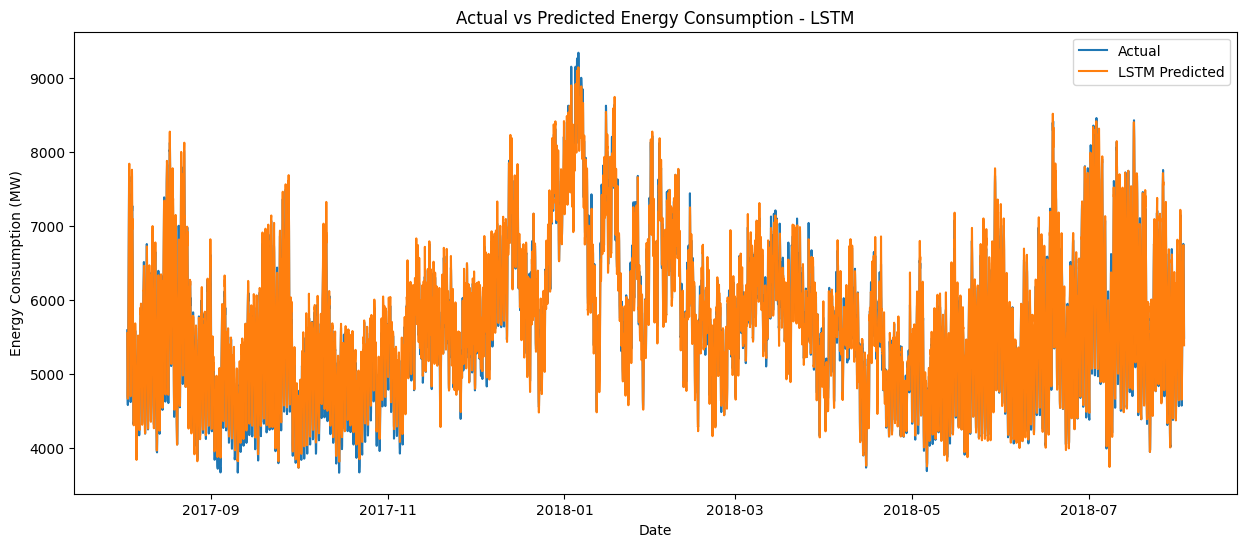

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(seq_dates[test_mask], y_lstm_test, label='Actual')
plt.plot(seq_dates[test_mask], lstm_pred, label='LSTM Predicted')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.title('Actual vs Predicted Energy Consumption - LSTM')
plt.legend()
plt.show()


## LSTM Training History


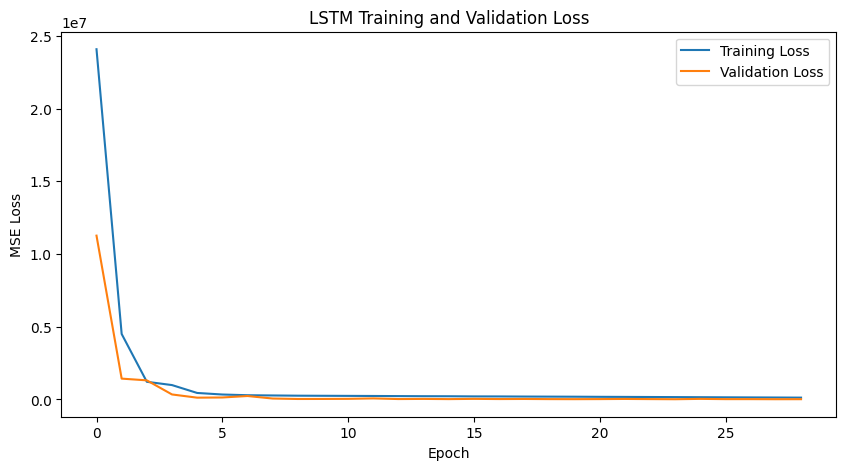

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [ ]:
# Build the RNN network

tf.random.set_seed(42)
np.random.seed(42)

rnn_model = Sequential([
    SimpleRNN(
        64,
        input_shape=(sequence_length, len(lstm_features)),
        return_sequences=True
    ),
    Dropout(0.2),

    SimpleRNN(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
rnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[rnn_early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - loss: 28056824.0000 - mae: 5197.0073 - val_loss: 19428810.0000 - val_mae: 4295.6616
Epoch 2/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - loss: 12445400.0000 - mae: 3330.1780 - val_loss: 6929730.0000 - val_mae: 2440.0066
Epoch 3/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - loss: 2619164.0000 - mae: 1317.3324 - val_loss: 1571104.5000 - val_mae: 968.1174
Epoch 4/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - loss: 1177224.1250 - mae: 864.3944 - val_loss: 989333.6250 - val_mae: 789.1855
Epoch 5/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - loss: 1160129.6250 - mae: 864.8789 - val_loss: 978218.1250 - val_mae: 793.7062
Epoch 6/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - loss: 1170704.5000 - mae: 868.7319 - val_loss: 977884.5625 - val_mae: 794.0630
Epoch 7/30
1886/1886 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - loss: 1190417.0000 - mae: 869.3836 - val_loss: 905790.0625 - val_mae: 768.2713
Epoch 8/30
1886/1886 ━━━━━━━━━

In [ ]:
rnn_predictions = rnn_model.predict(
    X_lstm_test,
    verbose=0
).flatten()

print("RNN predictions:", len(rnn_predictions))

RNN predictions: 8758


In [ ]:
rnn_mae = mean_absolute_error(y_lstm_test, rnn_predictions)
rnn_rmse = np.sqrt(mean_squared_error(y_lstm_test, rnn_predictions))
rnn_mape = mean_absolute_percentage_error(
    y_lstm_test,
    rnn_predictions
) * 100

print("RNN")
print("----------------")
print("MAE :", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape, "%")

RNN
----------------
MAE : 264.95758056640625
RMSE: 354.9583822436089
MAPE: 4.604807123541832 %


### ARIMA model

In [ ]:
!pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 24.8 MB/s eta 0:00:00


### Train-Test Split

In [ ]:
arima_train = train["PJMW_MW"]
arima_test = test["PJMW_MW"]

print("ARIMA Train:", len(arima_train))
print("ARIMA Test :", len(arima_test))

ARIMA Train: 134216
ARIMA Test : 8758


### ARIMA Fitting: ARIMA learns patterns from historical energy consumption data to make forecasts.

In [ ]:
print("Fitting ARIMA model...")

arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print("ARIMA model fitted successfully.")

Fitting ARIMA model...
ARIMA model fitted successfully.


In [ ]:
# Generate predictions matching test size
arima_predictions = arima_fit.forecast(steps=len(arima_test))

print("Predictions generated:", len(arima_predictions))

Predictions generated: 8758


In [ ]:
# Calculate Evaluation Metrics (MAE, RMSE, MAPE)

# Calculate Evaluation Metrics

mae_arima = mean_absolute_error(arima_test, arima_predictions)
rmse_arima = np.sqrt(mean_squared_error(arima_test, arima_predictions))
mape_arima = mean_absolute_percentage_error(arima_test, arima_predictions) * 100

print("ARIMA")
print("----------------")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima, "%")

ARIMA
----------------
MAE : 876.6783454856627
RMSE: 1137.0313014306812
MAPE: 14.447222478541702 %


### Evaluation Metrics: MAE, RMSE, and MAPE measure prediction errors and help compare ARIMA with other models.

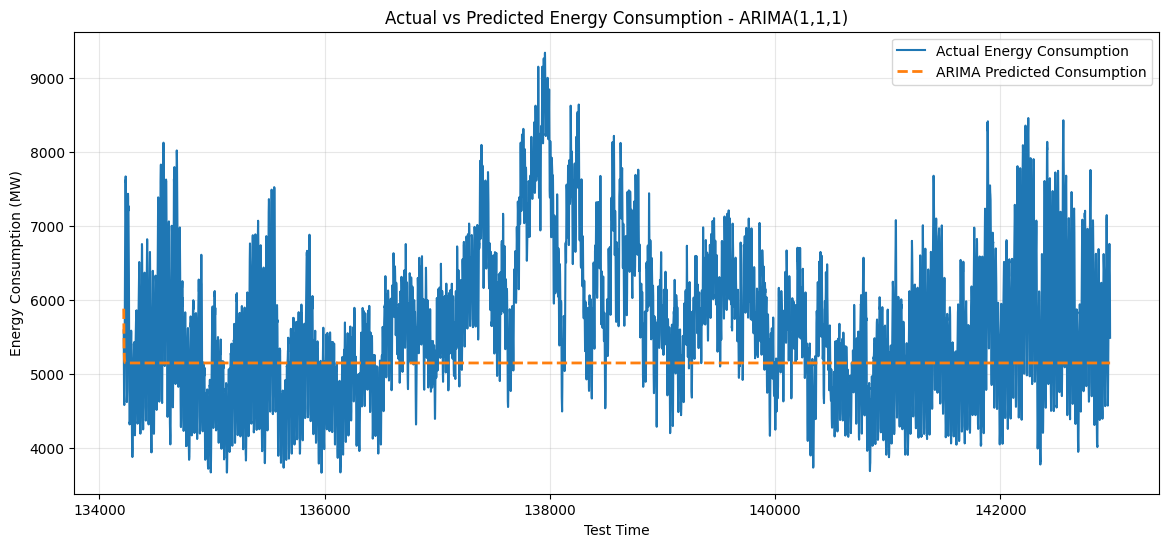

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    arima_test.index,
    arima_test.values,
    label='Actual Energy Consumption',
    linewidth=1.5
)

plt.plot(
    arima_test.index,
    arima_predictions,
    label='ARIMA Predicted Consumption',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Test Time')
plt.ylabel('Energy Consumption (MW)')
plt.title('Actual vs Predicted Energy Consumption - ARIMA(1,1,1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualization: The plot compares actual energy demand with ARIMA’s predicted values.

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost",
        "Tuned Random Forest",
        "RNN",
        "LSTM",
        "ARIMA"
    ],

    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        Tuned_xgb_mae,
        Tuned_rf_mae,
        rnn_mae,
        lstm_mae,
        mae_arima
    ],

    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        Tuned_xgb_rmse,
        Tuned_rf_rmse,
        rnn_rmse,
        lstm_rmse,
        rmse_arima
    ],

    "MAPE (%)": [
        baseline_mape * 100,
        rf_mape * 100,
        xgb_mape * 100,
        Tuned_xgb_mape * 100,
        Tuned_rf_mape * 100,
        rnn_mape,
        lstm_mape * 100,
        mape_arima
    ]
})

final_results

,Model,MAE,RMSE,MAPE (%)
0,Baseline,382.682119,501.400840,6.663327
1,Random Forest,58.961546,77.409093,1.030600
2,XGBoost,56.935843,79.143366,0.980901
3,Tuned XGBoost,56.500178,79.253018,0.974470
4,Tuned Random Forest,59.122098,77.689497,1.032957
5,RNN,230.954819,355.185031,3.849655
6,LSTM,114.841507,149.625790,2.008937
7,ARIMA,876.678345,1137.031301,14.447222


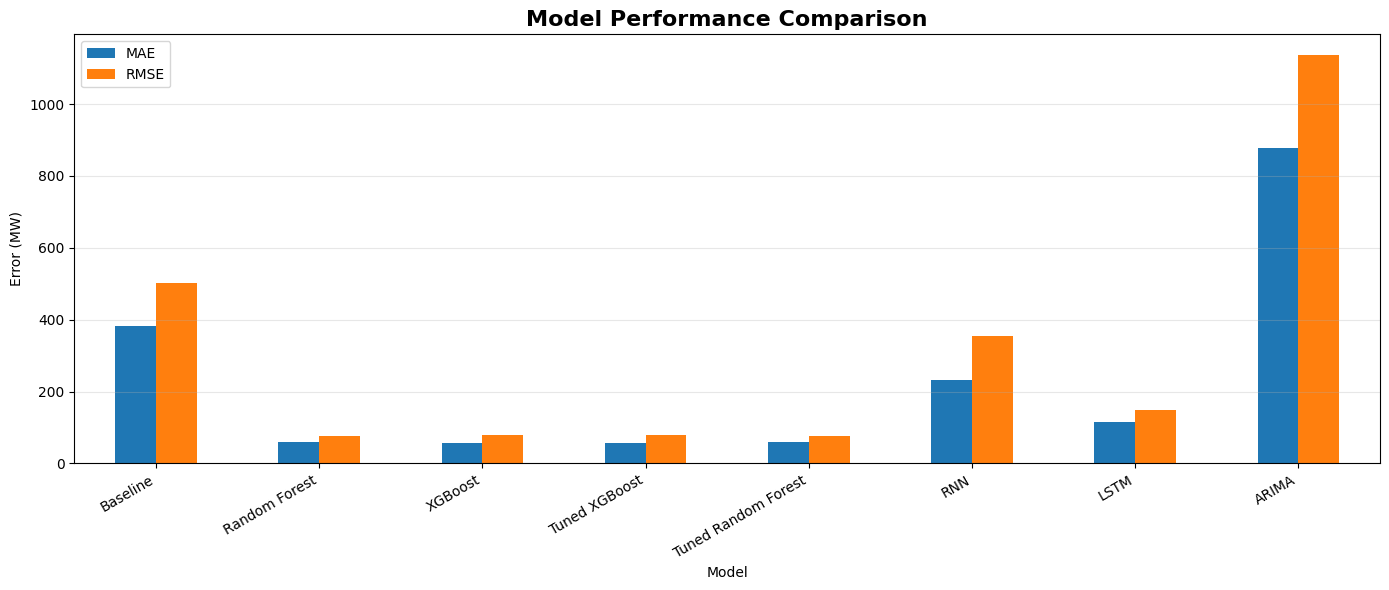

In [ ]:
final_results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Model Performance Comparison", fontsize=16, fontweight="bold")
plt.ylabel("Error (MW)")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## Save the Final Model (.pkl)
Tuned XGBoost had the best accuracy, so we retrain it on all the data and save it as a pickle file. 
The Streamlit app loads `xgb_model.pkl` and `PJMW_history.csv`.

In [ ]:
# ============================================================
#  SAVE MODEL (.pkl) + HISTORY FILE
# ============================================================
import pickle
import pandas as pd
from xgboost import XGBRegressor

# 1) Final model = Tuned XGBoost, trained on ALL data (train + test)
final_xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
)
final_xgb_model.fit(
    pd.concat([X_train, X_test]),
    pd.concat([y_train, y_test])
)

# 2) Put model + features + accuracy in one package
package = {
    "model": final_xgb_model,
    "features": features,
    "metrics": {
        "MAE": float(Tuned_xgb_mae),
        "RMSE": float(Tuned_xgb_rmse),
        "MAPE_%": float(Tuned_xgb_mape * 100),
    },
}

# 3) Save the pickle file
with open("xgb_model.pkl", "wb") as f:      # "wb" = write binary
    pickle.dump(package, f)
print("Saved: xgb_model.pkl")

# 4) Save the history file (the app needs it to start the forecast)
history = df[["Datetime", "PJMW_MW"]].copy()
history["Datetime"] = pd.to_datetime(history["Datetime"])
history = history.sort_values("Datetime")
history.to_csv("PJMW_history.csv", index=False)
print("Saved: PJMW_history.csv", history.shape)

# 5) Test: load the pickle file and predict
with open("xgb_model.pkl", "rb") as f:      # "rb" = read binary
    loaded = pickle.load(f)
print("Features:", loaded["features"])
print("Metrics :", loaded["metrics"])
print("Test prediction:", loaded["model"].predict(X_test[features].head(3)))


